# Bbox Detection YOLO 训练脚本（二类别版本）

使用与 `insulator_yolo_training_v2.ipynb` 相同的训练流程

## 数据集信息
- **数据来源**: `data/yolo_dataset_2class`
- **图像数量**: 基于13张原始图像进行数据增强
- **类别数量**: 2 类 (abnormal, normal)
- **类别ID映射**: 
  - 0: abnormal（异常）
  - 1: normal（正常）
- **标注格式**: YOLO格式（已从LabelMe转换）

## 注意事项
- 类别按照字母顺序分配ID（abnormal, normal）
- 数据已包含增强样本
- 直接运行即可训练

## 0. 项目初始化

In [37]:
import os
from pathlib import Path

# 清除 Ultralytics 缓存
cache_dir = os.path.expanduser('~/.cache/ultralytics/')
if os.path.exists(cache_dir):
    print(f"缓存目录: {cache_dir}")
    print("缓存文件:")
    for f in os.listdir(cache_dir):
        print(f"  - {f}")

# 项目根目录
current_path = Path.cwd()
PROJECT_ROOT = Path('/bwopt/MODELS/hj/VL/YOLO_SEGMENT')

# 创建实验目录
directories = [
    "experiments",
    "experiments_checkpoints",
    "configs",
    "logs"
]

for dir_path in directories:
    full_path = PROJECT_ROOT / dir_path
    full_path.mkdir(parents=True, exist_ok=True)

print("✓ 项目目录创建完成")
print(f"项目根目录: {PROJECT_ROOT}")

✓ 项目目录创建完成
项目根目录: /bwopt/MODELS/hj/VL/YOLO_SEGMENT


## 1. 安装依赖

In [38]:
!pip install ultralytics pyyaml -q

from ultralytics import YOLO
import yaml
from pathlib import Path
from datetime import datetime

print("✓ 依赖库导入完成")

✓ 依赖库导入完成


## 2. 创建数据集配置文件

In [ ]:
# Bbox Detection 数据集路径（二类别数据集）
BBOX_DATA_DIR = PROJECT_ROOT / 'data' / 'yolo_dataset_2class_new'

# 检查数据集是否存在
if not BBOX_DATA_DIR.exists():
    print(f"⚠️ 数据集不存在: {BBOX_DATA_DIR}")
    print("请先运行数据处理脚本创建 YOLO 格式数据集")
else:
    print(f"✓ 数据集路径: {BBOX_DATA_DIR}")
    
    # 统计数据集
    train_images = len(list((BBOX_DATA_DIR / 'train' / 'images').glob('*.JPG')))
    val_images = len(list((BBOX_DATA_DIR / 'val' / 'images').glob('*.JPG')))
    test_images = len(list((BBOX_DATA_DIR / 'test' / 'images').glob('*.JPG')))
    
    print(f"\n数据集统计:")
    print(f"  训练集: {train_images} 张")
    print(f"  验证集: {val_images} 张")
    print(f"  测试集: {test_images} 张")
    print(f"  总计: {train_images + val_images + test_images} 张")
    
    # 保存数据集统计信息供后续使用
    DATASET_STATS = {
        'train_images': train_images,
        'val_images': val_images,
        'test_images': test_images,
        'total_images': train_images + val_images + test_images
    }

In [40]:
# 创建 YAML 配置文件
DATA_YAML_PATH = BBOX_DATA_DIR / 'data.yaml'

yaml_content = f"""# Bbox Detection Dataset
path: {BBOX_DATA_DIR}
train: train/images
val: val/images
test: test/images

nc: 2
names:
  0: abnormal
  1: normal
"""

with open(DATA_YAML_PATH, 'w', encoding='utf-8') as f:
    f.write(yaml_content)

# 复制到 configs 目录
CONFIG_YAML_PATH = PROJECT_ROOT / 'configs' / 'bbox_data_2class.yaml'
CONFIG_YAML_PATH.parent.mkdir(exist_ok=True)

import shutil
shutil.copy(DATA_YAML_PATH, CONFIG_YAML_PATH)

print(f"✓ 配置文件已创建:")
print(f"  - {DATA_YAML_PATH}")
print(f"  - {CONFIG_YAML_PATH}")

✓ 配置文件已创建:
  - /bwopt/MODELS/hj/VL/YOLO_SEGMENT/data/yolo_dataset_2class_new/data.yaml
  - /bwopt/MODELS/hj/VL/YOLO_SEGMENT/configs/bbox_data_2class.yaml


## 3. 配置实验参数

**重要**：每次训练前修改实验名称！

In [ ]:
# ==================== 实验配置 ====================

# 实验命名
EXPERIMENT_NAME = "bbox_yolo11x_2class_newdata_balance_exp007_base005_cls"  # 修改此值！

# 模型配置
MODEL_WEIGHTS = '/bwopt/MODELS/hj/VL/YOLO_SEGMENT/experiments/20260211_094441_bbox_yolo11x_exp005_bs16_is1600_gpu4_datav3/weights/best.pt'

# 训练参数
EPOCHS = 200
BATCH_SIZE = 8
IMAGE_SIZE = 1280
DEVICES = '2,3'  # 真实物理卡号


# 优化器参数
LR0 = 0.01
LRF = 0.01
OPTIMIZER = 'auto'

# 数据增强
MOSAIC = 0.8
AUGMENT = True

# ==================== 生成实验目录 ====================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
experiment_dir = PROJECT_ROOT / 'experiments' / f"{timestamp}_{EXPERIMENT_NAME}"
experiment_dir.mkdir(parents=True, exist_ok=True)

# ==================== 获取数据集统计信息 ====================
total_images = DATASET_STATS.get('total_images', '未知')
train_images = DATASET_STATS.get('train_images', '未知')
val_images = DATASET_STATS.get('val_images', '未知')
test_images = DATASET_STATS.get('test_images', '未知')

# ==================== 获取系统和环境信息 ====================
import platform
import subprocess
import torch

# 获取 GPU 信息
def get_gpu_info():
    try:
        result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], 
                              capture_output=True, text=True)
        gpu_info = result.stdout.strip().split('\n')
        return {f"gpu_{i}": info.strip() for i, info in enumerate(gpu_info)}
    except:
        return {"gpu_info": "无法获取"}

# 获取 YOLO 版本
def get_yolo_version():
    try:
        import ultralytics
        return ultralytics.__version__
    except:
        return "未知"

# 获取 Python 环境
def get_python_packages():
    packages = ['torch', 'torchvision', 'ultralytics', 'cv2', 'numpy', 'pandas']
    pkg_info = {}
    for pkg in packages:
        try:
            if pkg == 'cv2':
                import cv2
                pkg_info['opencv'] = cv2.__version__
            elif pkg == 'ultralytics':
                import ultralytics
                pkg_info[pkg] = ultralytics.__version__
            else:
                mod = __import__(pkg)
                pkg_info[pkg] = mod.__version__
        except:
            pkg_info[pkg] = "未安装"
    return pkg_info

# ==================== 统计数据集类别分布 ====================
def count_labels(label_dir):
    """统计每个类别的标注框数量"""
    normal_count = 0
    abnormal_count = 0
    if label_dir.exists():
        for label_file in label_dir.glob('*.txt'):
            with open(label_file, 'r') as f:
                for line in f:
                    class_id = int(line.strip().split()[0])
                    if class_id == 0:
                        abnormal_count += 1
                    elif class_id == 1:
                        normal_count += 1
    return abnormal_count, normal_count

train_abnormal, train_normal = count_labels(BBOX_DATA_DIR / 'train' / 'labels')
val_abnormal, val_normal = count_labels(BBOX_DATA_DIR / 'val' / 'labels')
test_abnormal, test_normal = count_labels(BBOX_DATA_DIR / 'test' / 'labels')

total_abnormal = train_abnormal + val_abnormal + test_abnormal
total_normal = train_normal + val_normal + test_normal
total_labels = total_abnormal + total_normal

# ==================== 打印配置 ====================
print("="*60)
print("实验配置")
print("="*60)
print(f"实验名称: {EXPERIMENT_NAME}")
print(f"实验目录: {experiment_dir.name}")
print(f"\n【模型配置】")
print(f"  权重: {Path(MODEL_WEIGHTS).name}")
print(f"  完整路径: {MODEL_WEIGHTS}")

print(f"\n【训练参数】")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Image Size: {IMAGE_SIZE}")
print(f"  Device: {DEVICES}")

print(f"\n【数据集统计 (动态)】")
print(f"  总图片数: {total_images} 张")
print(f"    - 训练集: {train_images} 张")
print(f"    - 验证集: {val_images} 张")
print(f"    - 测试集: {test_images} 张")
print(f"  总标注框数: {total_labels} 个")
print(f"    - abnormal (类别0): {total_abnormal} 个 ({total_abnormal/total_labels*100:.1f}%)")
print(f"      * 训练集: {train_abnormal}")
print(f"      * 验证集: {val_abnormal}")
print(f"      * 测试集: {test_abnormal}")
print(f"    - normal (类别1): {total_normal} 个 ({total_normal/total_labels*100:.1f}%)")
print(f"      * 训练集: {train_normal}")
print(f"      * 验证集: {val_normal}")
print(f"      * 测试集: {test_normal}")
print(f"  类别数: 2 类")
print(f"    - 0: abnormal（异常）")
print(f"    - 1: normal（正常）")
print(f"  数据不平衡比: {total_normal/total_abnormal:.2f}:1")

print(f"\n【优化器配置】")
print(f"  Initial LR: {LR0}")
print(f"  Final LR: {LRF}")
print(f"  Optimizer: {OPTIMIZER}")

print(f"\n【数据增强】")
print(f"  Mosaic: {MOSAIC}")
print(f"  Augment: {AUGMENT}")
print(f"  建议: 训练时添加 copy_paste=0.5, mixup=0.15")

print(f"\n【系统信息】")
print(f"  Python: {platform.python_version()}")
print(f"  PyTorch: {torch.__version__}")
print(f"  CUDA: {torch.version.cuda}")
print(f"  YOLO: {get_yolo_version()}")

print(f"\n【环境依赖】")
pkg_info = get_python_packages()
for pkg, version in pkg_info.items():
    print(f"  {pkg}: {version}")

print(f"\n【硬件信息】")
gpu_info = get_gpu_info()
for gpu_name, info in gpu_info.items():
    print(f"  {gpu_name}: {info}")
print(f"  可用GPU: {torch.cuda.device_count()} 个")
print("="*60)

# ==================== 保存详细配置 ====================
config = {
    # 基本信息
    'experiment_name': EXPERIMENT_NAME,
    'experiment_dir': str(experiment_dir),
    'timestamp': timestamp,
    
    # 模型配置
    'model': {
        'weights_path': str(MODEL_WEIGHTS),
        'weights_name': Path(MODEL_WEIGHTS).name,
    },
    
    # 数据集信息
    'dataset': {
        'name': 'bbox_detection_2class',
        'path': str(BBOX_DATA_DIR),
        'num_classes': 2,
        'classes': ['abnormal', 'normal'],
        'class_mapping': {
            '0': 'abnormal',
            '1': 'normal'
        },
    },
    
    # 数据集统计
    'dataset_stats': {
        'images': {
            'total': total_images,
            'train': train_images,
            'val': val_images,
            'test': test_images,
        },
        'labels': {
            'total': total_labels,
            'abnormal': {
                'total': total_abnormal,
                'train': train_abnormal,
                'val': val_abnormal,
                'test': test_abnormal,
                'percentage': round(total_abnormal/total_labels*100, 2)
            },
            'normal': {
                'total': total_normal,
                'train': train_normal,
                'val': val_normal,
                'test': test_normal,
                'percentage': round(total_normal/total_labels*100, 2)
            },
            'imbalance_ratio': round(total_normal/total_abnormal, 2)
        }
    },
    
    # 训练参数
    'training': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'image_size': IMAGE_SIZE,
        'device': DEVICES,
        'workers': 8,
        'cache': False,
        'patience': 50,
        'save': True,
        'plots': True,
        'amp': False,
        'pretrained': True,
    },
    
    # 优化器配置
    'optimizer': {
        'name': OPTIMIZER,
        'lr0': LR0,
        'lrf': LRF,
        'momentum': 0.937,
        'weight_decay': 0.0005,
    },
    
    # 数据增强
    'augmentation': {
        'mosaic': MOSAIC,
        'augment': AUGMENT,
        'hsv_h': 0.015,
        'hsv_s': 0.7,
        'hsv_v': 0.4,
        'degrees': 0.0,
        'translate': 0.1,
        'scale': 0.5,
        'shear': 0.0,
        'perspective': 0.0,
        'flipud': 0.0,
        'fliplr': 0.5,
        'mosaic': MOSAIC,
        'mixup': 0.0,
        'copy_paste': 0.0,
    },
    
    # 损失函数权重
    'loss_weights': {
        'box': 7.5,
        'cls': 0.7,
        'dfl': 1.5,
    },
    
    # 系统信息
    'system': {
        'python_version': platform.python_version(),
        'pytorch_version': torch.__version__,
        'cuda_version': torch.version.cuda,
        'yolo_version': get_yolo_version(),
        'gpu_count': torch.cuda.device_count(),
        'gpu_info': gpu_info,
    },
    
    # 环境依赖
    'environment': pkg_info,
    
    # 项目信息
    'project': {
        'root': str(PROJECT_ROOT),
        'name': 'YOLO_SEGMENT',
    },
}

# 保存配置文件
config_path = experiment_dir / 'config.yaml'
with open(config_path, 'w', encoding='utf-8') as f:
    yaml.dump(config, f, allow_unicode=True, default_flow_style=False)

print(f"\n✓ 详细配置已保存到: {config_path}")

# 同时保存为 JSON 格式（方便读取）
import json
config_json_path = experiment_dir / 'config.json'
with open(config_json_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print(f"✓ JSON格式配置已保存到: {config_json_path}")

## 4. 开始训练

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = DEVICES

# 加载模型
print(f"正在加载模型: {MODEL_WEIGHTS}")
model = YOLO(str(MODEL_WEIGHTS))

# 重建模型头部以匹配2类别
print(f"重建模型头部：从预训练模型适配到2类别")
print(f"  - 原始类别数: {model.model.model[-1].nc if hasattr(model.model, 'model') else '未知'}")
print(f"  - 目标类别数: 2 (abnormal, normal)")

# 开始训练
print("\n开始训练...")
print("-" * 60)
print(f"实验目录: {experiment_dir.name}")
print(f"数据集: bbox_detection_2class")
print(f"类别: abnormal(0), normal(1)")
print(f"使用设备: {DEVICES}")
print("-" * 60)

results = model.train(
    data=str(DATA_YAML_PATH),
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMAGE_SIZE,
    device=DEVICES,
    cls=0.7,
    project=str(experiment_dir.parent),
    name=experiment_dir.name,
    verbose=True,
    patience=50,
    save=True,
    plots=True,
    amp=False,  # 禁用 AMP，避免兼容性问题
    exist_ok=True,
    optimizer=OPTIMIZER,
    lr0=LR0,
    lrf=LRF,
    mosaic=MOSAIC,
    augment=AUGMENT,
    workers=8,  # 设置数据加载线程数为8
    # cache=False,  # 禁用缓存减少显存占用
    pretrained=True,  # 使用预训练权重
)

print("\n" + "="*60)
print("训练完成！")
print(f"实验结果保存在: {experiment_dir}")
print("="*60)

正在加载模型: /bwopt/MODELS/hj/VL/YOLO_SEGMENT/experiments/20260211_094441_bbox_yolo11x_exp005_bs16_is1600_gpu4_datav3/weights/best.pt


重建模型头部：从预训练模型适配到2类别
  - 原始类别数: 1
  - 目标类别数: 2 (abnormal, normal)

开始训练...
------------------------------------------------------------
实验目录: 20260311_141836_bbox_yolo11x_2class_newdata_balance_exp007_base005_fl_gamma
数据集: bbox_detection_2class
类别: abnormal(0), normal(1)
使用设备: 2,3
------------------------------------------------------------
New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'


SyntaxError: '[31m[1mfl_gamma[0m' is not a valid YOLO argument. 

    Arguments received: ['yolo', '--f=/run/user/1001/jupyter/runtime/kernel-v3b4028a3049d7dac9c3be4e3a14cac4d777087a6e.json']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of ['segment', 'classify', 'pose', 'obb', 'detect']
                MODE (required) is one of ['val', 'track', 'train', 'export', 'benchmark', 'predict']
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at https://docs.ultralytics.com/usage/cfg or with 'yolo cfg'

    1. Train a detection model for 10 epochs with an initial learning_rate of 0.01
        yolo train data=coco8.yaml model=yolo26n.pt epochs=10 lr0=0.01

    2. Predict a YouTube video using a pretrained segmentation model at image size 320:
        yolo predict model=yolo26n-seg.pt source='https://youtu.be/LNwODJ

## 5. 查看训练结果


results.png:


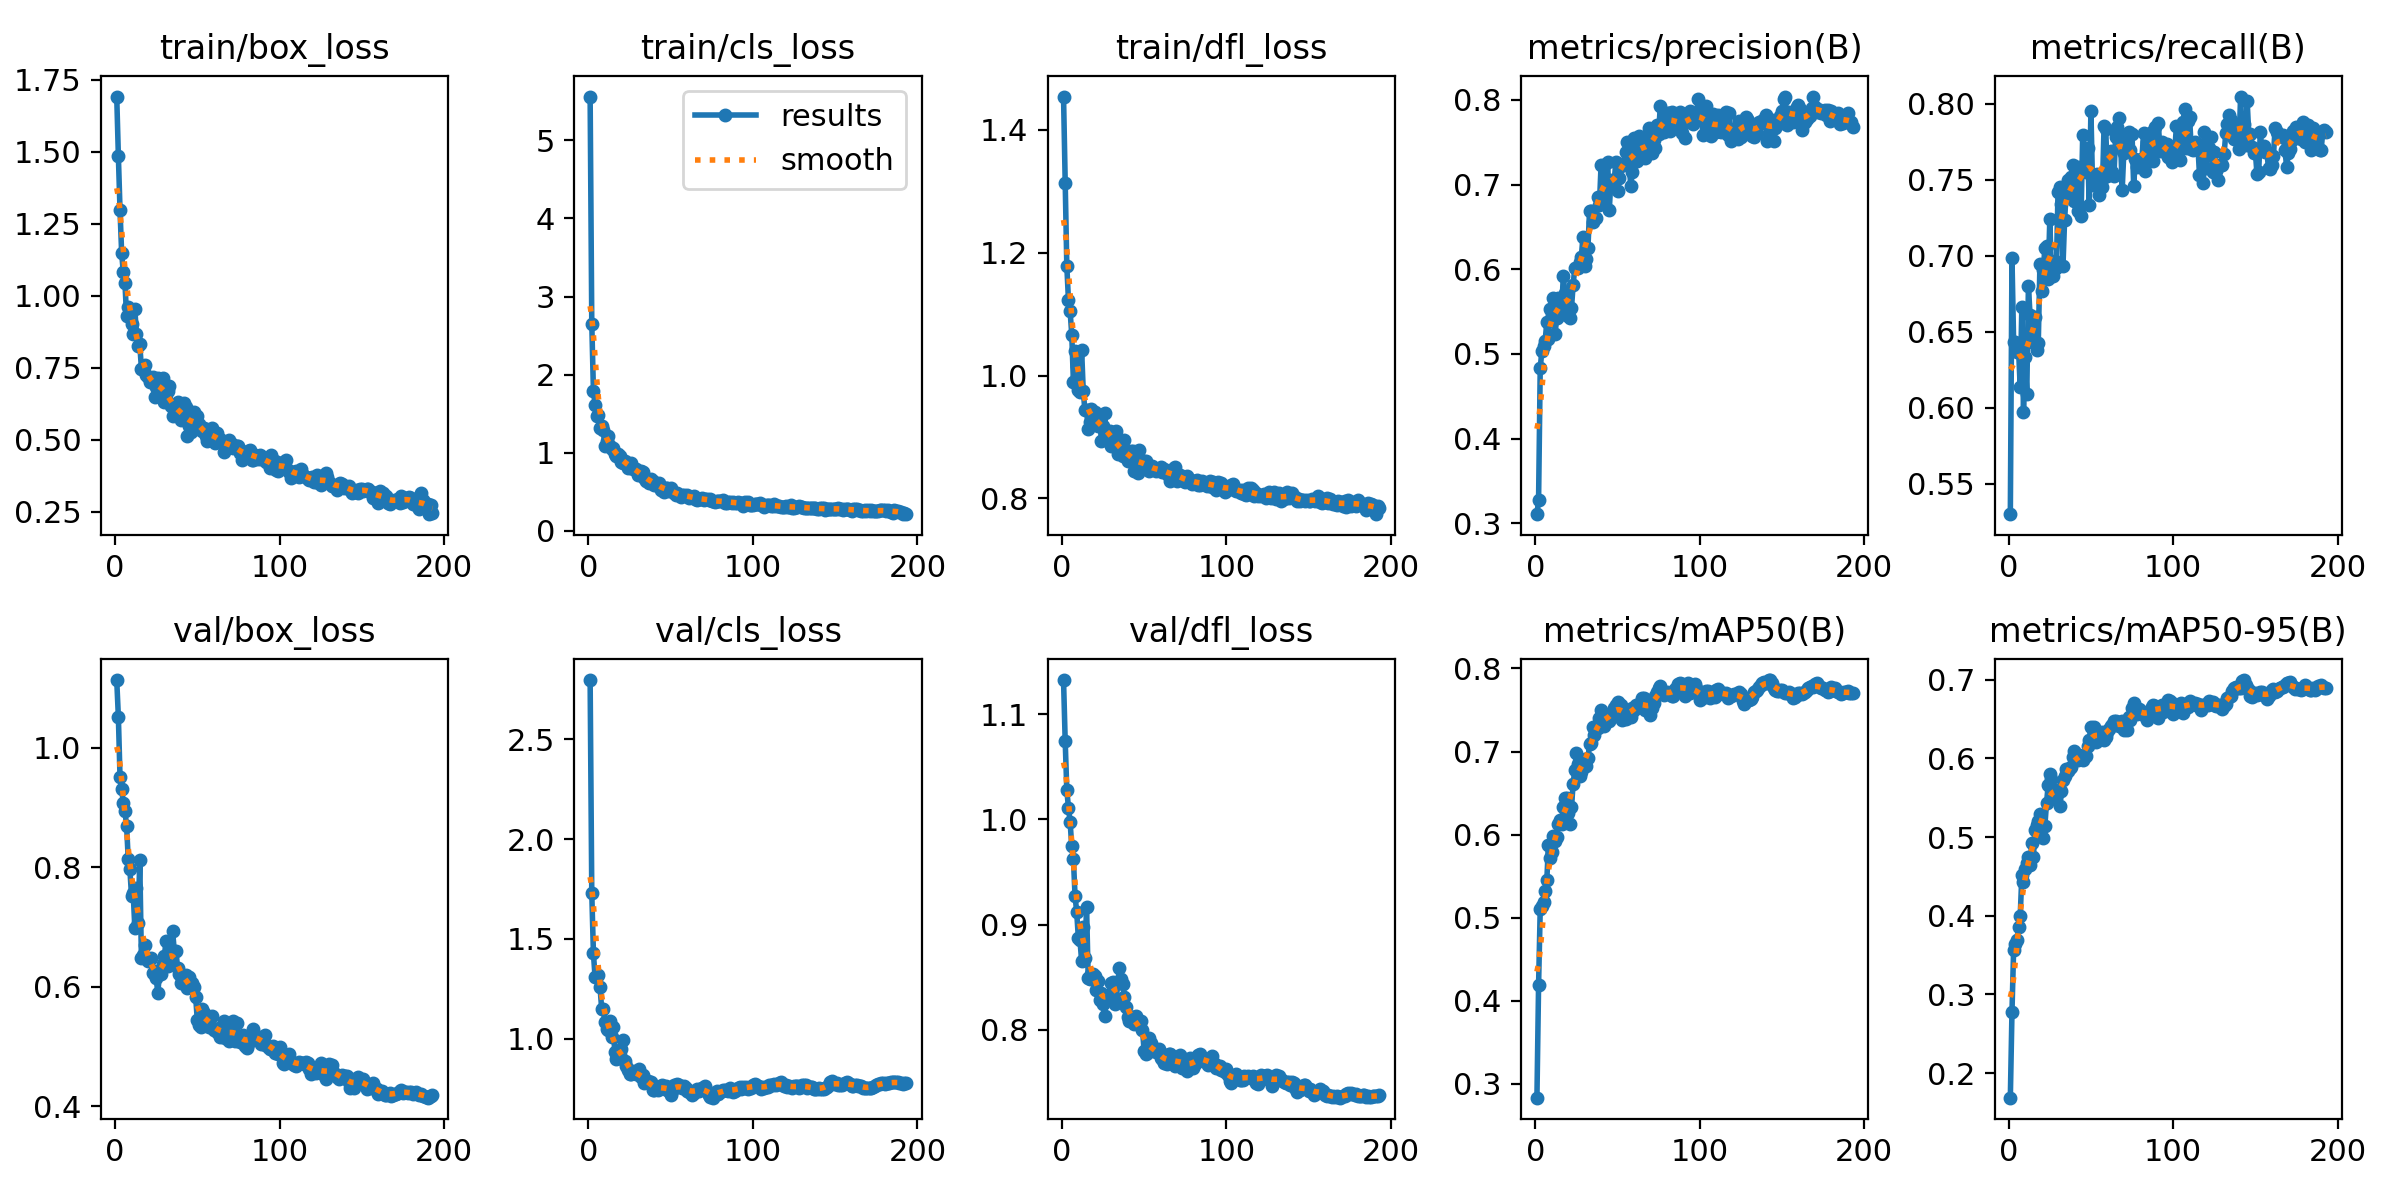


confusion_matrix.png:


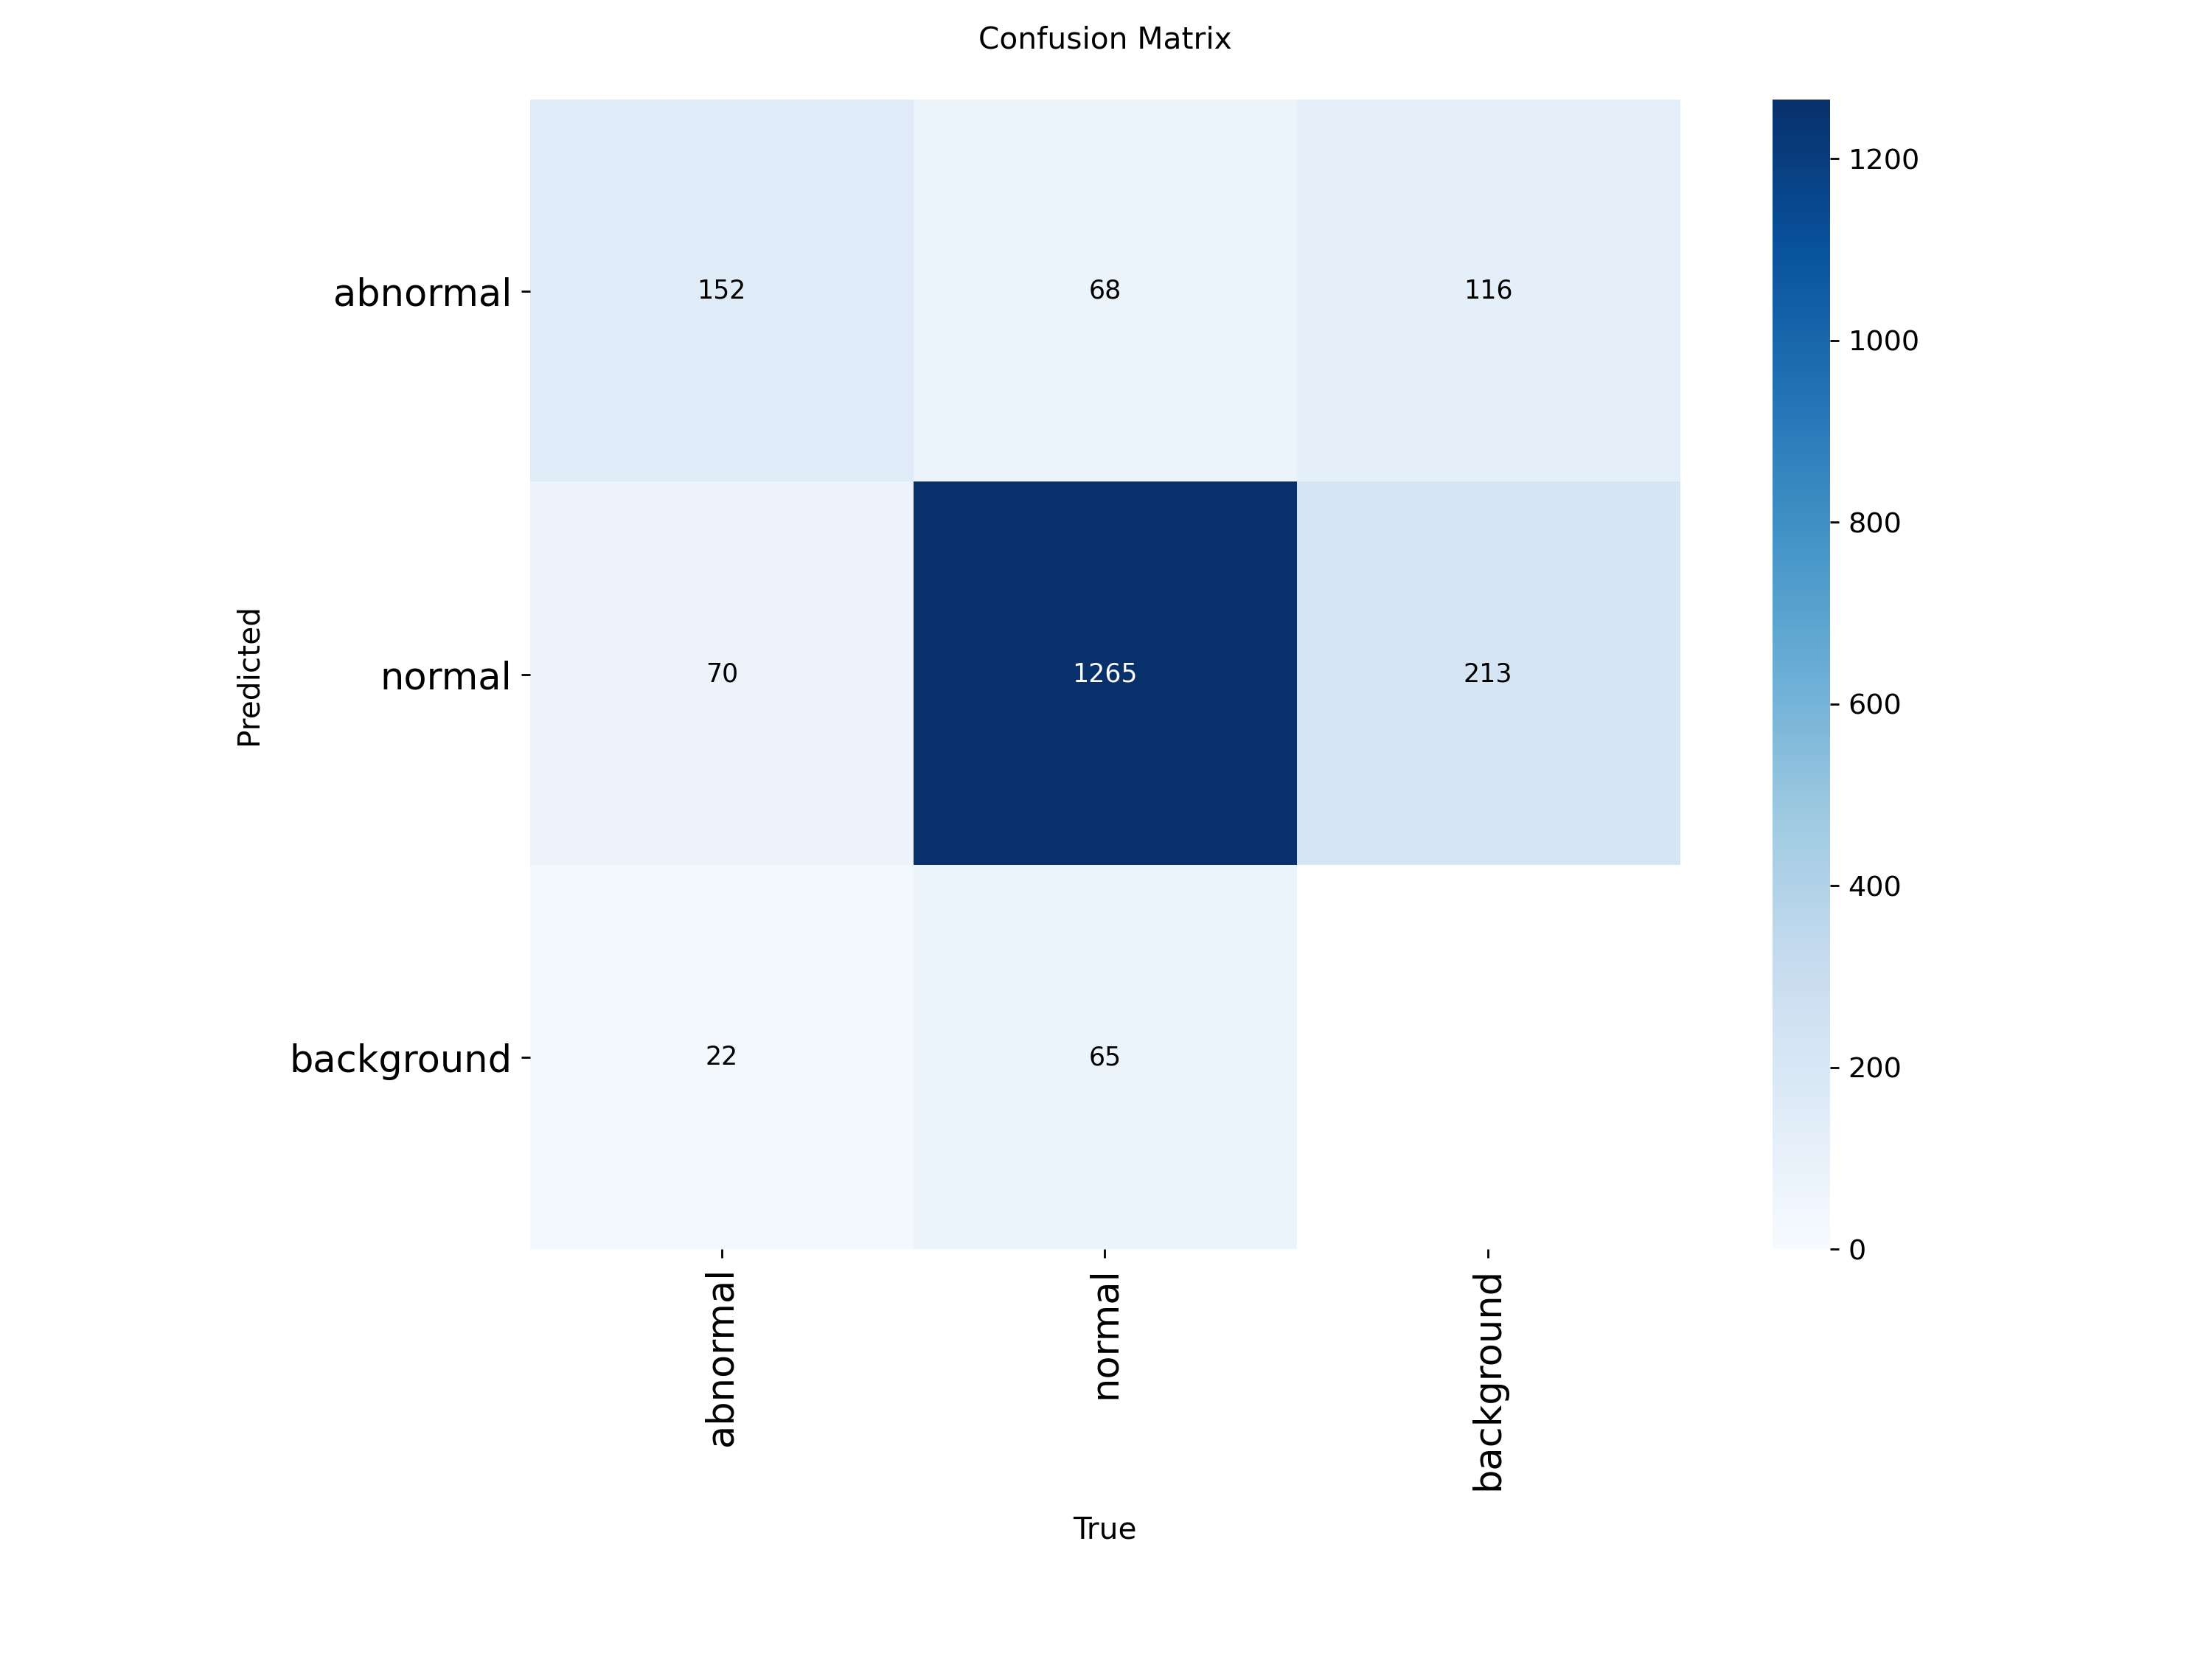

In [ ]:
# 显示训练结果图片
from IPython.display import Image, display

result_images = ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'F1_curve.png']

for img_name in result_images:
    img_path = experiment_dir / img_name
    if img_path.exists():
        print(f"\n{img_name}:")
        display(Image(filename=str(img_path), width=600))

## 6. 创建实验记录

In [ ]:
# 读取训练结果
results_file = experiment_dir / 'results.csv'

if results_file.exists():
    import pandas as pd
    df = pd.read_csv(results_file)
    last_row = df.iloc[-1]
    
    # 读取配置信息
    config_path = experiment_dir / 'config.json'
    if config_path.exists():
        import json
        with open(config_path, 'r', encoding='utf-8') as f:
            config = json.load(f)
    else:
        config = {}
    
    # 获取数据集统计信息
    dataset_stats = config.get('dataset_stats', {})
    img_stats = dataset_stats.get('images', {})
    label_stats = dataset_stats.get('labels', {})
    
    total_images = img_stats.get('total', DATASET_STATS.get('total_images', '未知'))
    train_images = img_stats.get('train', DATASET_STATS.get('train_images', '未知'))
    val_images = img_stats.get('val', DATASET_STATS.get('val_images', '未知'))
    test_images = img_stats.get('test', DATASET_STATS.get('test_images', '未知'))
    
    total_labels = label_stats.get('total', '未知')
    abnormal_labels = label_stats.get('abnormal', {}).get('total', '未知')
    normal_labels = label_stats.get('normal', {}).get('total', '未知')
    imbalance_ratio = label_stats.get('imbalance_ratio', '未知')
    
    # 获取系统信息
    system_info = config.get('system', {})
    yolo_version = system_info.get('yolo_version', '未知')
    
    # 创建实验记录
    readme_content = f"""# 实验记录: {EXPERIMENT_NAME}

## 📊 数据集信息

- **数据集名称**: bbox_detection_2class
- **总样本数**: {total_images} 张图片
  - 训练集: {train_images} 张
  - 验证集: {val_images} 张
  - 测试集: {test_images} 张
- **总标注框数**: {total_labels} 个
  - **abnormal (类别0)**: {abnormal_labels} 个 ({label_stats.get('abnormal', {}).get('percentage', 'N/A')}%)
  - **normal (类别1)**: {normal_labels} 个 ({label_stats.get('normal', {}).get('percentage', 'N/A')}%)
- **数据不平衡比**: {imbalance_ratio}:1
- **类别映射**:
  - `0`: abnormal（异常）- 红色
  - `1`: normal（正常）- 绿色

## ⚙️ 训练配置

### 基本参数
- **实验时间**: {timestamp}
- **模型权重**: {config.get('model', {}).get('weights_name', 'N/A')}
- **训练轮数**: {EPOCHS} epochs
- **批次大小**: {BATCH_SIZE}
- **图像尺寸**: {IMAGE_SIZE}×{IMAGE_SIZE}
- **GPU设备**: {DEVICES}

### 优化器配置
- **优化器**: {OPTIMIZER}
- **初始学习率**: {LR0}
- **最终学习率**: {LRF}

### 数据增强
- **Mosaic**: {MOSAIC}
- **Augment**: {AUGMENT}
- **建议**: 训练时添加 `copy_paste=0.5`, `mixup=0.15` 以处理类别不平衡

### 系统环境
- **Python**: {system_info.get('python_version', 'N/A')}
- **PyTorch**: {system_info.get('pytorch_version', 'N/A')}
- **CUDA**: {system_info.get('cuda_version', 'N/A')}
- **YOLO版本**: {yolo_version}
- **GPU数量**: {system_info.get('gpu_count', 'N/A')} 个

## 📈 训练结果

### 最终性能指标
- **最终 Epoch**: {int(last_row.get('epoch', 0)) + 1} / {EPOCHS}
- **mAP50@0.5**: {last_row.get('metrics/mAP50(B)', 'N/A')}
- **mAP50-95**: {last_row.get('metrics/mAP50-95(B)', 'N/A')}
- **精确率 (Precision)**: {last_row.get('metrics/precision(B)', 'N/A')}
- **召回率 (Recall)**: {last_row.get('metrics/recall(B)', 'N/A')}

### 损失指标
- **Box Loss**: {last_row.get('train/box_loss', 'N/A')}
- **Cls Loss**: {last_row.get('train/cls_loss', 'N/A')}
- **DFL Loss**: {last_row.get('train/dfl_loss', 'N/A')}

## 💬 结论

_请在此填写实验结论：_
- _模型性能是否满足要求？_
- _是否存在过拟合/欠拟合？_
- _哪些超参数调整有效？_
- _下一步改进方向？_

## 📝 备注

_请在此填写其他备注信息：_
- _训练过程中的异常情况_
- _特殊的数据处理步骤_
- _其他需要注意的事项_

---
**配置文件**: [config.yaml](config.yaml) | [config.json](config.json)  
**生成时间**: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
"""
    
    readme_path = experiment_dir / 'README.md'
    readme_path.write_text(readme_content, encoding='utf-8')
    print(f"✓ 实验记录已创建: {readme_path}")
    print(f"✓ 使用动态数据集统计:")
    print(f"  - 总图片: {total_images} 张")
    print(f"  - 总标注: {total_labels} 个 (abnormal: {abnormal_labels}, normal: {normal_labels})")
    print(f"  - 不平衡比: {imbalance_ratio}:1")
else:
    print("⚠ 未找到训练结果文件")

## 使用说明

### 完整训练流程

1. **首次运行** - 运行第0-2节，初始化和创建配置文件
2. **配置实验** - 运行第3节，修改 `EXPERIMENT_NAME` 和 `DEVICE`
3. **开始训练** - 运行第4节
4. **查看结果** - 运行第5-6节

### 下次训练新实验

只需重新运行 **第3、4、5、6节**，记得修改 `EXPERIMENT_NAME`！

### 与 insulator_yolo_training_v2.ipynb 同时运行

两个脚本使用不同的 GPU 即可同时训练：
- `insulator_yolo_training_v2.ipynb`: DEVICE='0'  
- `bbox_training.ipynb`: DEVICE='1'

### 实验命名规范

```python
EXPERIMENT_NAME = "bbox_yolo26x_exp001"  # 实验1
EXPERIMENT_NAME = "bbox_yolo26x_exp002_bs16"  # 实验2，batch=16
EXPERIMENT_NAME = "bbox_yolo26x_lr001"  # 实验3，lr=0.001
```